#Hough Transform

Saving crop_field_c.jpg to crop_field_c (10).jpg
Hough Transform Angle (degrees): -45.0


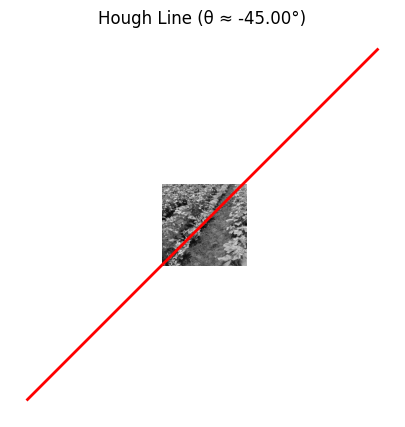

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

edges = cv2.Canny(img, 100, 200)

# Hough Transform
lines = cv2.HoughLines(edges, 1, np.pi/180, 150)

if lines is not None:
    rho, theta = lines[0][0]
    theta_hough = np.degrees(theta) - 90
    print("Hough Transform Angle (degrees):", theta_hough)

    # Convert polar to Cartesian
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a*rho
    y0 = b*rho
    x1 = int(x0 + 1000*(-b))
    y1 = int(y0 + 1000*(a))
    x2 = int(x0 - 1000*(-b))
    y2 = int(y0 - 1000*(a))

    # Plot
    plt.figure(figsize=(8,5))
    plt.imshow(img, cmap='gray')
    plt.plot([x1,x2],[y1,y2],'r', linewidth=2)
    plt.title(f"Hough Line (θ ≈ {theta_hough:.2f}°)")
    plt.axis("off")
    plt.show()
else:
    print("No lines detected by Hough Transform. so we have Adjust Canny / Hough parameters")

    plt.figure(figsize=(8,5))
    plt.imshow(edges, cmap='gray')
    plt.title("Edges (No lines detected)")
    plt.axis("off")
    plt.show()